<a href="https://colab.research.google.com/github/Hessa-codding-house/AIHC5020-byHessa/blob/main/HomeWork2_ByHessa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 0: Installing Required Pandas

In [1]:
# Install DuckDB in the current Colab runtime.
%pip -q install duckdb

# Import the libraries used in the assignment.
import os
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

# Make wide DataFrames easier to inspect in Colab.
pd.set_option('display.max_columns', None)

print('Setup completed successfully.')

Setup completed successfully.


Part 1: Problem #1

In [2]:
# METHOD 1: LIST OF DICTIONARIES
# The outer list contains rows. Each dictionary represents one row.
students_list_of_dicts = [
    {'StudentID': 101, 'Name': 'Alice',   'Score': 85, 'Major': 'Computer Science'},
    {'StudentID': 102, 'Name': 'Bob',     'Score': 92, 'Major': 'Physics'},
    {'StudentID': 103, 'Name': 'Charlie', 'Score': 78, 'Major': 'Mathematics'},
    {'StudentID': 104, 'Name': 'David',   'Score': 95, 'Major': 'Computer Science'},
    {'StudentID': 105, 'Name': 'Eve',     'Score': 88, 'Major': 'Biology'},
    {'StudentID': 106, 'Name': 'Frank',   'Score': 72, 'Major': 'Mathematics'},
    {'StudentID': 107, 'Name': 'Grace',   'Score': 99, 'Major': 'Physics'},
    {'StudentID': 108, 'Name': 'Heidi',   'Score': 81, 'Major': 'Biology'},
    {'StudentID': 109, 'Name': 'Ivan',    'Score': 90, 'Major': 'Computer Science'},
    {'StudentID': 110, 'Name': 'Judy',    'Score': 84, 'Major': 'Mathematics'}
]

student_df_method1 = pd.DataFrame(students_list_of_dicts)
print('Method 1: List of dictionaries')
print(student_df_method1)


# METHOD 2: DICTIONARY OF LISTS
# Each key is a column name, and each list contains one complete column.
students_dict_of_lists = {
    'StudentID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve',
             'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'Score': [85, 92, 78, 95, 88, 72, 99, 81, 90, 84],
    'Major': ['Computer Science', 'Physics', 'Mathematics',
              'Computer Science', 'Biology', 'Mathematics',
              'Physics', 'Biology', 'Computer Science', 'Mathematics']
}

student_df_method2 = pd.DataFrame(students_dict_of_lists)
print('\nMethod 2: Dictionary of lists')
print(student_df_method2)


# METHOD 3: LIST OF LISTS
# Each inner list contains one row. Column names must be supplied separately.
students_list_of_lists = [
    [101, 'Alice',   85, 'Computer Science'],
    [102, 'Bob',     92, 'Physics'],
    [103, 'Charlie', 78, 'Mathematics'],
    [104, 'David',   95, 'Computer Science'],
    [105, 'Eve',     88, 'Biology'],
    [106, 'Frank',   72, 'Mathematics'],
    [107, 'Grace',   99, 'Physics'],
    [108, 'Heidi',   81, 'Biology'],
    [109, 'Ivan',    90, 'Computer Science'],
    [110, 'Judy',    84, 'Mathematics']
]

student_columns = ['StudentID', 'Name', 'Score', 'Major']
student_df_method3 = pd.DataFrame(students_list_of_lists,
                                  columns=student_columns)

print('\nMethod 3: List of lists')
print(student_df_method3)


# Confirm that the three methods produced exactly the same DataFrame.
print('\nMethod 1 equals Method 2:', student_df_method1.equals(student_df_method2))
print('Method 1 equals Method 3:', student_df_method1.equals(student_df_method3))

# Use one copy as student_df for Problems 2–6.
student_df = student_df_method1.copy()

Method 1: List of dictionaries
   StudentID     Name  Score             Major
0        101    Alice     85  Computer Science
1        102      Bob     92           Physics
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics
6        107    Grace     99           Physics
7        108    Heidi     81           Biology
8        109     Ivan     90  Computer Science
9        110     Judy     84       Mathematics

Method 2: Dictionary of lists
   StudentID     Name  Score             Major
0        101    Alice     85  Computer Science
1        102      Bob     92           Physics
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics
6        107    Grace     99           Physics
7        108    Heidi     81           Biolog

Part 1- Problem 2


In [3]:
# 1. Select the complete row whose index label is 3.
print('1. Complete row at index 3:')
print(student_df.loc[3])

# 2. The colon means all rows; 'Score' identifies one column.
print('\n2. Score column for all students:')
print(student_df.loc[:, 'Score'])

# 3. Select one cell using a row label and a column label.
print('\n3. Major of the student at index 6:')
print(student_df.loc[6, 'Major'])

# 4. .loc includes both index 2 and index 5.
print('\n4. Rows from index 2 through index 5:')
print(student_df.loc[2:5])

# 5. Lists allow selection of several row and column labels.
print('\n5. Name and Major for indices 0, 4, and 9:')
print(student_df.loc[[0, 4, 9], ['Name', 'Major']])

1. Complete row at index 3:
StudentID                 104
Name                    David
Score                      95
Major        Computer Science
Name: 3, dtype: object

2. Score column for all students:
0    85
1    92
2    78
3    95
4    88
5    72
6    99
7    81
8    90
9    84
Name: Score, dtype: int64

3. Major of the student at index 6:
Physics

4. Rows from index 2 through index 5:
   StudentID     Name  Score             Major
2        103  Charlie     78       Mathematics
3        104    David     95  Computer Science
4        105      Eve     88           Biology
5        106    Frank     72       Mathematics

5. Name and Major for indices 0, 4, and 9:
    Name             Major
0  Alice  Computer Science
4    Eve           Biology
9   Judy       Mathematics


Problem 1: Part3

In [4]:
# Create a new DataFrame indexed by StudentID.
df_reindexed = student_df.set_index('StudentID')

print('DataFrame indexed by StudentID:')
print(df_reindexed)

# Bob = 102, David = 104, and Grace = 107.
print('\nBob, David, and Grace selected with .loc:')
print(df_reindexed.loc[[102, 104, 107]])

DataFrame indexed by StudentID:
              Name  Score             Major
StudentID                                  
101          Alice     85  Computer Science
102            Bob     92           Physics
103        Charlie     78       Mathematics
104          David     95  Computer Science
105            Eve     88           Biology
106          Frank     72       Mathematics
107          Grace     99           Physics
108          Heidi     81           Biology
109           Ivan     90  Computer Science
110           Judy     84       Mathematics

Bob, David, and Grace selected with .loc:
            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
107        Grace     99           Physics


Problem 2: Part 4

In [5]:
# Bob is at position 1, David at 3, and Grace at 6.
selected_with_iloc = df_reindexed.iloc[[1, 3, 6]]

print('Bob, David, and Grace selected with .iloc:')
print(selected_with_iloc)

Bob, David, and Grace selected with .iloc:
            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
107        Grace     99           Physics


Part 1: Problem 5

In [7]:
# 1. Boolean indexing for Mathematics majors.
mathematics_boolean_series = df_reindexed['Major'] == 'Mathematics'

print('Boolean Series for Mathematics majors:')
print(mathematics_boolean_series)

print('\nMathematics students:')
print(df_reindexed.loc[mathematics_boolean_series])

# 2. Query students whose Score is strictly greater than 85.
print('\nStudents with Score greater than 85:')
print(df_reindexed.query('Score > 85'))

Boolean Series for Mathematics majors:
StudentID
101    False
102    False
103     True
104    False
105    False
106     True
107    False
108    False
109    False
110     True
Name: Major, dtype: bool

Mathematics students:
              Name  Score        Major
StudentID                             
103        Charlie     78  Mathematics
106          Frank     72  Mathematics
110           Judy     84  Mathematics

Students with Score greater than 85:
            Name  Score             Major
StudentID                                
102          Bob     92           Physics
104        David     95  Computer Science
105          Eve     88           Biology
107        Grace     99           Physics
109         Ivan     90  Computer Science


Part 1: Problem 6

In [8]:
def find_top_student_in_major(df, major_name):
    # Filter to rows that match the requested major.
    major_df = df.loc[df['Major'] == major_name]

    # Handle a major that does not occur in the DataFrame.
    if major_df.empty:
        print(f"No students were found in the major '{major_name}'.")
        return None

    # Descending order places the highest score first.
    sorted_major_df = major_df.sort_values(by='Score', ascending=False)

    # .iloc[0] selects the first row; the column list returns Name and Score.
    top_student = sorted_major_df.iloc[0][['Name', 'Score']]
    return top_student


print('Top Computer Science student:')
print(find_top_student_in_major(student_df, 'Computer Science'))

print('\nTop Physics student:')
print(find_top_student_in_major(student_df, 'Physics'))

print('\nTop Chemistry student:')
chemistry_result = find_top_student_in_major(student_df, 'Chemistry')
if chemistry_result is not None:
    print(chemistry_result)

Top Computer Science student:
Name     David
Score       95
Name: 3, dtype: object

Top Physics student:
Name     Grace
Score       99
Name: 6, dtype: object

Top Chemistry student:
No students were found in the major 'Chemistry'.


Problem 2- Part 0

In [13]:
# ============================================================
# PART 2 SETUP: IMPORT, UPLOAD, AND LOAD THE CSV FILES
# ============================================================

# Install DuckDB in the current Colab runtime.
%pip -q install duckdb

# Import the required libraries.
import io
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

from google.colab import files


# Colab cannot directly access a Windows path beginning with:
# C:\Users\...
#
# Therefore, use the file-selection window to upload the two
# CSV files from your Windows/OneDrive folder.

print(
    "Please select BOTH files:\n"
    "1. healthcare-dataset-stroke-data.csv\n"
    "2. location_codes.csv"
)

uploaded = files.upload()


# Get the names of the files selected during this upload.
uploaded_file_names = list(uploaded.keys())

print("\nUploaded files:")

for file_name in uploaded_file_names:
    print("-", file_name)


# Identify the main stroke-data file.
# Searching by part of the filename means this will still work
# if Colab adds something such as (1) to a repeated upload.

stroke_file_candidates = [
    file_name
    for file_name in uploaded_file_names
    if (
        "healthcare-dataset-stroke-data" in file_name.lower()
        and file_name.lower().endswith(".csv")
    )
]


# Identify the location-code file.

location_file_candidates = [
    file_name
    for file_name in uploaded_file_names
    if (
        "location_codes" in file_name.lower()
        and file_name.lower().endswith(".csv")
    )
]


# Verify that exactly one stroke file was found.

if len(stroke_file_candidates) != 1:
    raise FileNotFoundError(
        "Could not identify exactly one "
        "healthcare-dataset-stroke-data.csv file. "
        "Rerun this cell and select the correct file."
    )


# Verify that exactly one location file was found.

if len(location_file_candidates) != 1:
    raise FileNotFoundError(
        "Could not identify exactly one location_codes.csv file. "
        "Rerun this cell and select the correct file."
    )


# Store the detected filenames.

stroke_file_name = stroke_file_candidates[0]
location_file_name = location_file_candidates[0]


# Read the uploaded file contents into pandas DataFrames.

stroke_df = pd.read_csv(
    io.BytesIO(uploaded[stroke_file_name])
)

location_codes_df = pd.read_csv(
    io.BytesIO(uploaded[location_file_name])
)


# Remove accidental spaces from the beginnings or ends
# of the column names.

stroke_df.columns = stroke_df.columns.str.strip()

location_codes_df.columns = (
    location_codes_df.columns.str.strip()
)


# Display basic information to verify that loading worked.

print("\nstroke_df shape:")
print(stroke_df.shape)

print("\nlocation_codes_df shape:")
print(location_codes_df.shape)

print("\nFirst five rows of stroke_df:")
print(stroke_df.head())

print("\nFirst five rows of location_codes_df:")
print(location_codes_df.head())

print("\nstroke_df columns:")
print(stroke_df.columns.tolist())

print("\nlocation_codes_df columns:")
print(location_codes_df.columns.tolist())

print("\nMissing values in stroke_df:")
print(stroke_df.isna().sum())


# Verify the columns required by the assignment.

required_stroke_columns = {
    "id",
    "gender",
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "avg_glucose_level",
    "bmi",
    "smoking_status",
    "stroke",
    "location_code"
}

required_location_columns = {
    "location_code",
    "city",
    "state"
}


missing_stroke_columns = (
    required_stroke_columns.difference(stroke_df.columns)
)

missing_location_columns = (
    required_location_columns.difference(
        location_codes_df.columns
    )
)


if missing_stroke_columns:
    raise KeyError(
        "The main stroke file is missing these columns: "
        + ", ".join(sorted(missing_stroke_columns))
    )

if missing_location_columns:
    raise KeyError(
        "The location-code file is missing these columns: "
        + ", ".join(sorted(missing_location_columns))
    )


print("\nBoth CSV files were loaded and verified successfully.")

Please select BOTH files:
1. healthcare-dataset-stroke-data.csv
2. location_codes.csv


Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data (1).csv
Saving location_codes.csv to location_codes (1).csv

Uploaded files:
- healthcare-dataset-stroke-data (1).csv
- location_codes (1).csv

stroke_df shape:
(5110, 13)

location_codes_df shape:
(112, 3)

First five rows of stroke_df:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             10

Probelm 2- Part 2

In [14]:
# ============================================================
# PROBLEM 7
# APPLY A ROW-LEVEL FUNCTION TO CREATE A NEW COLUMN
# ============================================================


def cardiovascular_disease_from_row(row):
    """
    Return 1 if the person has hypertension or heart disease.
    Return 0 if the person has neither condition.
    """

    # Access the two values from the current row.
    hypertension_value = row["hypertension"]
    heart_disease_value = row["heart_disease"]

    # "or" means either condition is sufficient.
    if (
        hypertension_value == 1
        or heart_disease_value == 1
    ):
        return 1
    else:
        return 0


# axis=1 tells pandas to apply the function row by row.
# The resulting Series is assigned to the new column.

stroke_df["cardiovascular_disease"] = stroke_df.apply(
    cardiovascular_disease_from_row,
    axis=1
)


# Verify the new column.

print(
    "First rows of hypertension, heart disease, "
    "and cardiovascular disease:"
)

print(
    stroke_df[
        [
            "hypertension",
            "heart_disease",
            "cardiovascular_disease"
        ]
    ].head(10)
)


print("\nValue counts for cardiovascular_disease:")

print(
    stroke_df["cardiovascular_disease"]
    .value_counts()
    .sort_index()
)

First rows of hypertension, heart disease, and cardiovascular disease:
   hypertension  heart_disease  cardiovascular_disease
0             0              1                       1
1             0              0                       0
2             0              1                       1
3             0              0                       0
4             1              0                       1
5             0              0                       0
6             1              1                       1
7             0              0                       0
8             0              0                       0
9             0              0                       0

Value counts for cardiovascular_disease:
cardiovascular_disease
0    4400
1     710
Name: count, dtype: int64


Problem 2: Part 3

In [15]:
# ============================================================
# PROBLEM 7
# APPLY A ROW-LEVEL FUNCTION TO CREATE A NEW COLUMN
# ============================================================


def cardiovascular_disease_from_row(row):
    """
    Return 1 if the person has hypertension or heart disease.
    Return 0 if the person has neither condition.
    """

    # Access the two values from the current row.
    hypertension_value = row["hypertension"]
    heart_disease_value = row["heart_disease"]

    # "or" means either condition is sufficient.
    if (
        hypertension_value == 1
        or heart_disease_value == 1
    ):
        return 1
    else:
        return 0


# axis=1 tells pandas to apply the function row by row.
# The resulting Series is assigned to the new column.

stroke_df["cardiovascular_disease"] = stroke_df.apply(
    cardiovascular_disease_from_row,
    axis=1
)


# Verify the new column.

print(
    "First rows of hypertension, heart disease, "
    "and cardiovascular disease:"
)

print(
    stroke_df[
        [
            "hypertension",
            "heart_disease",
            "cardiovascular_disease"
        ]
    ].head(10)
)


print("\nValue counts for cardiovascular_disease:")

print(
    stroke_df["cardiovascular_disease"]
    .value_counts()
    .sort_index()
)

First rows of hypertension, heart disease, and cardiovascular disease:
   hypertension  heart_disease  cardiovascular_disease
0             0              1                       1
1             0              0                       0
2             0              1                       1
3             0              0                       0
4             1              0                       1
5             0              0                       0
6             1              1                       1
7             0              0                       0
8             0              0                       0
9             0              0                       0

Value counts for cardiovascular_disease:
cardiovascular_disease
0    4400
1     710
Name: count, dtype: int64


Problem 2- Part 4

In [16]:
# ============================================================
# PROBLEM 8
# EXPLORATORY HISTOGRAMS BY CATEGORY
# ============================================================


def plot_histograms_by_category(
    df,
    continuous_col,
    categorical_col
):
    """
    Plot the distribution of a continuous variable separately
    for each group in a categorical variable.

    According to the assignment's heuristic, a column with
    fewer than 10 unique values is treated as categorical.
    """

    # --------------------------------------------------------
    # CHECK 1: CONFIRM THAT BOTH COLUMNS EXIST
    # --------------------------------------------------------

    missing_columns = [
        column
        for column in [continuous_col, categorical_col]
        if column not in df.columns
    ]

    if missing_columns:
        print(
            "The following column(s) were not found:",
            missing_columns
        )
        return None


    # --------------------------------------------------------
    # CHECK 2: COUNT UNIQUE VALUES
    # --------------------------------------------------------

    continuous_unique_count = (
        df[continuous_col].nunique(dropna=True)
    )

    categorical_unique_count = (
        df[categorical_col].nunique(dropna=True)
    )


    # A continuous variable should generally have at least
    # 10 unique values according to the assignment heuristic.

    if continuous_unique_count < 10:
        print(
            f"'{continuous_col}' has only "
            f"{continuous_unique_count} unique values. "
            "It appears to be categorical rather than continuous."
        )
        return None


    # A categorical variable should generally have fewer
    # than 10 unique values according to the assignment.

    if categorical_unique_count >= 10:
        print(
            f"'{categorical_col}' has "
            f"{categorical_unique_count} unique values. "
            "It appears to be continuous rather than categorical."
        )
        return None


    # --------------------------------------------------------
    # CREATE THE FIGURE AND AXES
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    # Find the unique, nonmissing categories.

    categories = (
        df[categorical_col]
        .dropna()
        .unique()
    )


    # --------------------------------------------------------
    # LOOP THROUGH THE CATEGORIES
    # --------------------------------------------------------

    for category in categories:

        # Keep only rows belonging to the current category.

        category_subset = df.loc[
            df[categorical_col] == category
        ]


        # Extract the continuous values and remove NaNs.

        continuous_values = (
            category_subset[continuous_col]
            .dropna()
        )


        # Add the histogram for this category.

        ax.hist(
            continuous_values,
            bins=20,
            alpha=0.6,
            edgecolor="black",
            label=f"{categorical_col} = {category}"
        )


    # --------------------------------------------------------
    # ADD THE TITLE, AXIS LABELS, AND LEGEND
    # --------------------------------------------------------

    ax.set_title(
        f"Distribution of {continuous_col} "
        f"by {categorical_col}"
    )

    ax.set_xlabel(continuous_col)
    ax.set_ylabel("Frequency")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return None

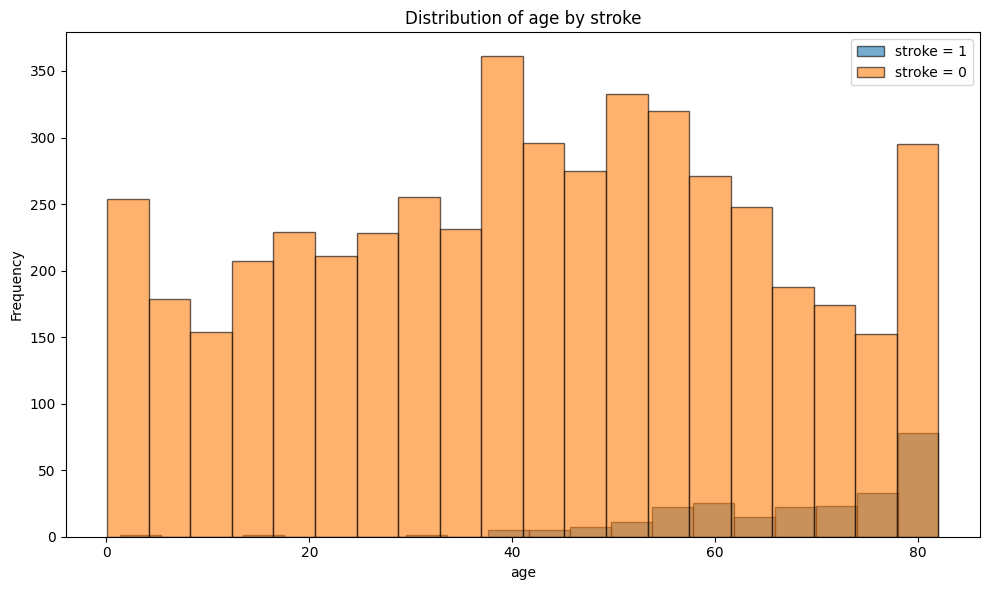

In [17]:
# TEST 1:
# Compare age distributions for stroke = 0 and stroke = 1.

plot_histograms_by_category(
    stroke_df,
    "age",
    "stroke"
)

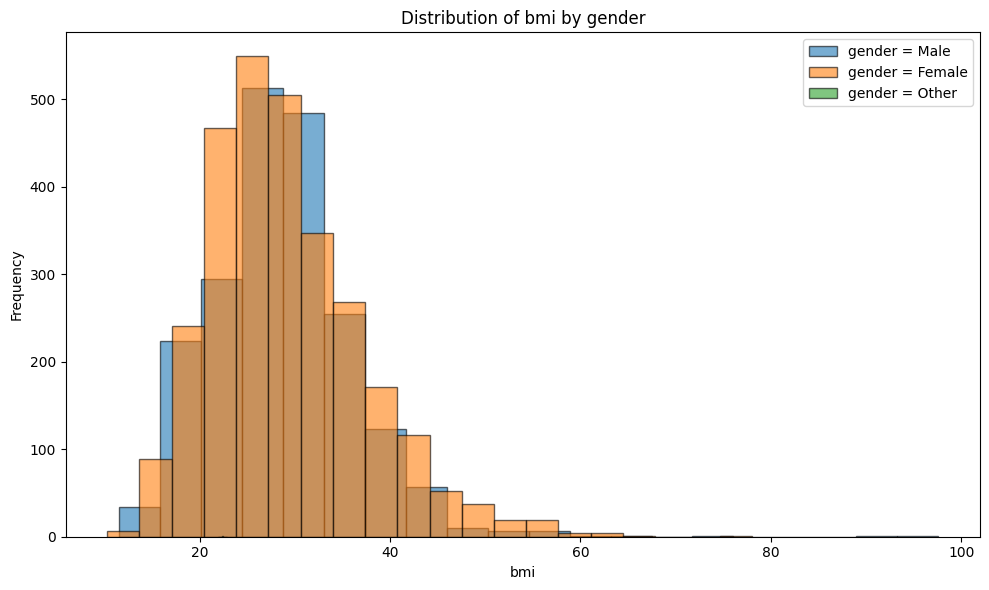

In [18]:
# TEST 2:
# Compare BMI distributions between gender groups.

plot_histograms_by_category(
    stroke_df,
    "bmi",
    "gender"
)

In [19]:
# TEST 3:
# This is deliberately incorrect.
# Stroke is categorical and age is continuous.
# The function should print a useful message and return None.

plot_histograms_by_category(
    stroke_df,
    "stroke",
    "age"
)

'stroke' has only 2 unique values. It appears to be categorical rather than continuous.


Problem 2- Part 5

In [20]:
# ============================================================
# PROBLEM 9
# CALCULATE GROUP-WISE STROKE PREVALENCE
# ============================================================


def calculate_stroke_prevalence(
    df,
    group_by_cols
):
    """
    Calculate stroke prevalence for groups defined by one
    or more categorical columns.

    Stroke prevalence =
    number of stroke cases / total number of people
    """

    # --------------------------------------------------------
    # CHECK 1: group_by_cols MUST BE A LIST
    # --------------------------------------------------------

    if not isinstance(group_by_cols, list):
        print(
            "group_by_cols must be a list "
            "of column-name strings."
        )
        return None


    if len(group_by_cols) == 0:
        print("group_by_cols cannot be an empty list.")
        return None


    if not all(
        isinstance(column, str)
        for column in group_by_cols
    ):
        print(
            "Every item in group_by_cols "
            "must be a string."
        )
        return None


    # --------------------------------------------------------
    # CHECK 2: CONFIRM THAT THE COLUMNS EXIST
    # --------------------------------------------------------

    missing_columns = [
        column
        for column in group_by_cols
        if column not in df.columns
    ]

    if missing_columns:
        print(
            "The following grouping column(s) "
            "were not found:",
            missing_columns
        )
        return None


    # --------------------------------------------------------
    # CHECK 3: CONFIRM THAT GROUPING COLUMNS ARE CATEGORICAL
    # --------------------------------------------------------

    noncategorical_columns = [
        column
        for column in group_by_cols
        if df[column].nunique(dropna=True) >= 10
    ]

    if noncategorical_columns:
        print(
            "The following column(s) appear to be continuous "
            "rather than categorical:",
            noncategorical_columns
        )
        return None


    # --------------------------------------------------------
    # CALCULATE GROUP SIZES
    # --------------------------------------------------------

    group_sizes = (
        df.groupby(group_by_cols)
        .size()
    )


    # Because stroke is represented by 0 and 1,
    # summing stroke gives the number of stroke cases.

    stroke_counts = (
        df.groupby(group_by_cols)["stroke"]
        .sum()
    )


    # Divide the stroke counts by the group sizes.

    stroke_prevalence = (
        stroke_counts / group_sizes
    )


    # Convert the Series into a tidy DataFrame.
    # reset_index() changes grouping-index values back
    # into ordinary DataFrame columns.

    prevalence_df = (
        stroke_prevalence
        .to_frame(name="stroke_prevalence")
        .reset_index()
    )

    return prevalence_df

In [21]:
# TEST 1:
# Stroke prevalence by smoking status.

smoking_prevalence = calculate_stroke_prevalence(
    stroke_df,
    ["smoking_status"]
)

print("Stroke prevalence by smoking_status:")

if smoking_prevalence is not None:
    print(smoking_prevalence)

Stroke prevalence by smoking_status:
    smoking_status  stroke_prevalence
0          Unknown           0.030440
1  formerly smoked           0.079096
2     never smoked           0.047569
3           smokes           0.053232


In [22]:
# TEST 2:
# Stroke prevalence grouped by two categorical columns.

marriage_work_prevalence = (
    calculate_stroke_prevalence(
        stroke_df,
        ["ever_married", "work_type"]
    )
)

print(
    "Stroke prevalence by ever_married "
    "and work_type:"
)

if marriage_work_prevalence is not None:
    print(marriage_work_prevalence)

Stroke prevalence by ever_married and work_type:
  ever_married      work_type  stroke_prevalence
0           No       Govt_job           0.051282
1           No   Never_worked           0.000000
2           No        Private           0.017052
3           No  Self-employed           0.063636
4           No       children           0.002911
5          Yes       Govt_job           0.050000
6          Yes        Private           0.064163
7          Yes  Self-employed           0.081805


In [23]:
# TEST 3:
# Age is continuous, so this should produce a useful message.

age_prevalence = calculate_stroke_prevalence(
    stroke_df,
    ["age"]
)

if age_prevalence is not None:
    print(age_prevalence)

The following column(s) appear to be continuous rather than categorical: ['age']


In [24]:
# TEST 4:
# This uses incorrect capitalization.
# The actual column is Residence_type, not residence_type.

incorrect_residence_prevalence = (
    calculate_stroke_prevalence(
        stroke_df,
        ["residence_type"]
    )
)

if incorrect_residence_prevalence is not None:
    print(incorrect_residence_prevalence)

The following grouping column(s) were not found: ['residence_type']


Problem 2- Part 5

In [25]:
# ============================================================
# PROBLEM 10
# BUILD A REUSABLE PREPROCESSING PIPELINE
# ============================================================


def preprocess_for_analysis(
    df,
    cols_to_impute,
    cols_to_scale,
    cols_to_encode,
    cols_to_drop
):
    """
    Prepare the input DataFrame for analysis.

    Processing order:
    1. Copy the original DataFrame.
    2. Drop unwanted columns.
    3. Mean-impute missing numerical values.
    4. Standardize numerical columns.
    5. One-hot encode categorical columns.
    """

    # --------------------------------------------------------
    # STEP 1: COPY THE ORIGINAL DATAFRAME
    # --------------------------------------------------------

    # This prevents the function from changing the original df.

    processed_df = df.copy()


    # --------------------------------------------------------
    # STEP 2: DROP UNWANTED COLUMNS
    # --------------------------------------------------------

    processed_df = processed_df.drop(
        columns=cols_to_drop
    )


    # --------------------------------------------------------
    # STEP 3: MEAN IMPUTATION
    # --------------------------------------------------------

    for column in cols_to_impute:

        # Calculate the mean while ignoring missing values.

        fill_value = processed_df[column].mean()


        # Replace NaN values with the calculated mean.

        processed_df[column] = (
            processed_df[column]
            .fillna(fill_value)
        )


    # --------------------------------------------------------
    # STEP 4: STANDARD SCALING
    # --------------------------------------------------------

    for column in cols_to_scale:

        # Calculate the mean and standard deviation.

        column_mean = processed_df[column].mean()

        column_standard_deviation = (
            processed_df[column].std()
        )


        # Create the name for the new scaled column.

        scaled_column_name = f"{column}_scaled"


        # Apply the z-score formula:
        # z = (x - mean) / standard deviation

        processed_df[scaled_column_name] = (
            processed_df[column] - column_mean
        ) / column_standard_deviation


        # Remove the original unscaled column.

        processed_df = processed_df.drop(
            columns=[column]
        )


    # --------------------------------------------------------
    # STEP 5: ONE-HOT ENCODING
    # --------------------------------------------------------

    # Create 0/1 columns for each categorical variable.
    # drop_first=True removes one reference category.
    # dtype=int ensures the new values are integers.

    encoded_columns_df = pd.get_dummies(
        processed_df[cols_to_encode],
        dtype=int,
        drop_first=True
    )


    # Remove the original categorical text columns.

    processed_df = processed_df.drop(
        columns=cols_to_encode
    )


    # Join the encoded columns to the remaining DataFrame.

    processed_df = processed_df.join(
        encoded_columns_df
    )


    return processed_df

In [26]:
# BMI is the numerical column with missing values
# in this stroke dataset.

impute_list = [
    "bmi"
]


# Numerical columns to standardize.

scale_list = [
    "age",
    "avg_glucose_level",
    "bmi"
]


# Categorical columns to one-hot encode.

encode_list = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]


# Identifier/location columns to remove from the
# analysis-ready DataFrame.

drop_list = [
    "id",
    "location_code"
]


# Run the preprocessing function.

processed_stroke_df = preprocess_for_analysis(
    df=stroke_df,
    cols_to_impute=impute_list,
    cols_to_scale=scale_list,
    cols_to_encode=encode_list,
    cols_to_drop=drop_list
)


print("First five rows of processed_stroke_df:")
print(processed_stroke_df.head())


print("\nInformation about processed_stroke_df:")
processed_stroke_df.info()


print("\nMissing values after preprocessing:")
print(processed_stroke_df.isna().sum())


print(
    "\nMeans of the scaled columns "
    "(should be approximately 0):"
)

print(
    processed_stroke_df[
        [
            "age_scaled",
            "avg_glucose_level_scaled",
            "bmi_scaled"
        ]
    ].mean()
)


print(
    "\nStandard deviations of the scaled columns "
    "(should be approximately 1):"
)

print(
    processed_stroke_df[
        [
            "age_scaled",
            "avg_glucose_level_scaled",
            "bmi_scaled"
        ]
    ].std()
)

First five rows of processed_stroke_df:
   hypertension  heart_disease  stroke  cardiovascular_disease  age_scaled  \
0             0              1       1                       1    1.051331   
1             0              0       1                       0    0.785993   
2             0              1       1                       1    1.626231   
3             0              0       1                       0    0.255317   
4             1              0       1                       1    1.582008   

   avg_glucose_level_scaled    bmi_scaled  gender_Male  gender_Other  \
0                  2.706111  1.001136e+00            1             0   
1                  2.121351  4.615102e-16            0             0   
2                 -0.005028  4.685314e-01            1             0   
3                  1.437217  7.153482e-01            0             0   
4                  1.501038 -6.356489e-01            0             0   

   ever_married_Yes  work_type_Never_worked  work_type_Pri

In [27]:
# ============================================================
# PROBLEM 11
# LEFT JOIN USING THE PANDAS MERGE METHOD
# ============================================================


# Confirm that the join column exists in both DataFrames.

if "location_code" not in stroke_df.columns:
    raise KeyError(
        "location_code was not found in stroke_df."
    )

if "location_code" not in location_codes_df.columns:
    raise KeyError(
        "location_code was not found in location_codes_df."
    )


# Perform the left join.
#
# stroke_df is the left DataFrame.
# location_codes_df is the right DataFrame.
# location_code is the join key.
# how='left' keeps every row from stroke_df.

merged_df = stroke_df.merge(
    location_codes_df,
    on="location_code",
    how="left"
)


print("First five rows of merged_df:")
print(merged_df.head())


print("\nLocation columns added by the merge:")

print(
    merged_df[
        [
            "location_code",
            "city",
            "state"
        ]
    ].head()
)


print("\nNumber of rows in stroke_df:")
print(len(stroke_df))

print("\nNumber of rows in merged_df:")
print(len(merged_df))


print("\nMissing city values after the merge:")
print(merged_df["city"].isna().sum())

print("\nMissing state values after the merge:")
print(merged_df["state"].isna().sum())

First five rows of merged_df:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  location_code  cardiovascular_disease          city state  
0       1            143   

Problem 2: Part 6

In [28]:
# ============================================================
# PROBLEM 12
# LEFT JOIN AND NEW YORK FILTER USING DUCKDB SQL
# ============================================================


# Triple quotation marks create a multiline Python string.
#
# s is an alias for stroke_df.
# l is an alias for location_codes_df.
#
# SELECT * means select all columns.
# LEFT JOIN combines the two DataFrames.
# ON specifies the matching location_code column.
# WHERE retains only rows whose state is NY.

sql_query = """
SELECT *
FROM stroke_df AS s
LEFT JOIN location_codes_df AS l
    ON s.location_code = l.location_code
WHERE l.state = 'NY'
"""


# Execute the query and convert the DuckDB result
# into a pandas DataFrame.

sql_result_df = (
    duckdb.query(sql_query)
    .to_df()
)


print("First five rows of sql_result_df:")
print(sql_result_df.head())


print("\nUnique values in the state column:")
print(sql_result_df["state"].unique())


print("\nNumber of New York rows:")
print(len(sql_result_df))

First five rows of sql_result_df:
      id  gender   age  hypertension  heart_disease ever_married  \
0  37937  Female  75.0             0              1           No   
1  17004  Female  70.0             0              0          Yes   
2  56841    Male  58.0             0              1          Yes   
3  20426  Female  78.0             1              0           No   
4  66767  Female  67.0             0              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi smoking_status  \
0  Self-employed          Urban             109.78   NaN        Unknown   
1        Private          Urban             221.58  47.5   never smoked   
2        Private          Rural             240.59  31.4         smokes   
3        Private          Urban             203.87  45.7   never smoked   
4       Govt_job          Rural              94.61  28.4         smokes   

   stroke  location_code  cardiovascular_disease  location_code_1      city  \
0       1            181   